In [8]:
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
import sys, os
sys.path.append('/bigdata/seth/ml-model/PyILC/pyilc')
sys.path.append('/bigdata/seth/ml-model/cmb-ml3/cmb-ml/cmbml/utils')
sys.path.append('/bigdata/aankit/lost_in_space')

from cmbml_old.utils.planck_cmap import colombi1_cmap
from time import time
import pysm3.units as u
import pysm3
# import sys
sys.path.append('/bigdata/seth/ml-model/cmb-ml')
from cmbml.core.asset_handlers import HealpyMap
os.environ['XDG_CONFIG_HOME'] = '/bigdata/cmb_project/xdg_home/xdg_config'
os.environ['XDG_CACHE_HOME'] = '/bigdata/cmb_project/xdg_home/xdg_cache'


In [ ]:
freqs = [100, 143, 217, 353]

lmax = 600
ells = np.arange(lmax + 1)

# Dummy Planck mean intensities (MJy/sr) for testing
MJysr = np.array([0.05, 0.12, 0.45, 2.3])  # replace with real values
centers = np.array(freqs)

# Placeholder Planck power spectra (use real dict in your project)
planckpsdict = {f: np.ones_like(ells) * (1e-5 * f) for f in freqs}

# Example binary mask (all-sky = ones)
nside = 2048
mask = np.ones(hp.nside2npix(nside))


In [16]:
# Make dictionary of dust maps for multiple models
dusts = ["d9"]  # d0 ... d12
pysmdict = {}

for dust in dusts:
    sky = pysm3.Sky(nside=nside, preset_strings=[dust])
    pysmdict[dust] = {}
    for freq in freqs:
        # Get Stokes I only
        dustmap = sky.get_emission(freq * u.GHz)[0].value
        pysmdict[dust][freq] = dustmap


In [17]:
def bias_to_planck(dust_model):
    meanvec = []
    for freq in freqs:
        dustmap = pysmdict[dust_model][freq]
        mean = np.sum(dustmap * mask) / np.sum(mask)
        meanvec.append(mean)

    meanvec = np.array(meanvec)

    # Compute per-frequency additive bias (independent offsets)
    biases = MJysr - meanvec

    # Error metric (chi^2 of means)
    err = meanvec + biases - MJysr
    chi = err @ err
    return biases, chi


In [18]:
for dust in dusts:
    biases, chi = bias_to_planck(dust)
    print(f"{dust}: Chi^2 = {chi:.4e}, Biases = {biases}")


d9: Chi^2 = 2.9163e-28, Biases = [ -57.4991837   -92.33730717 -155.06688106 -263.08264943]


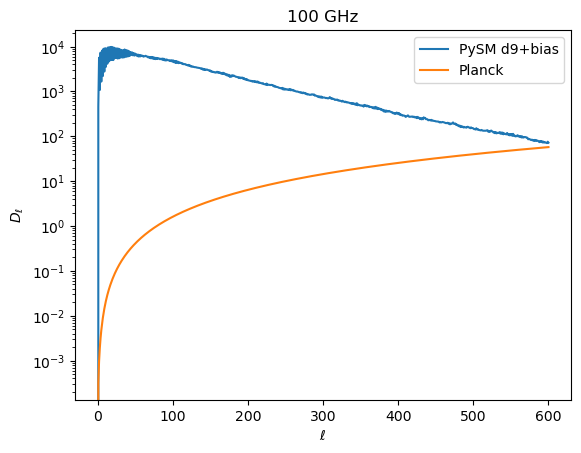

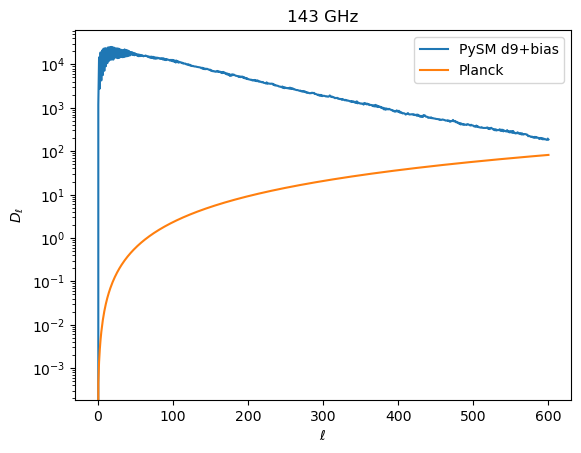

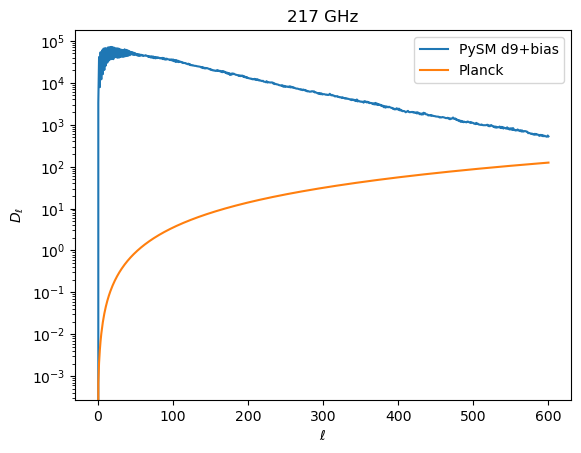

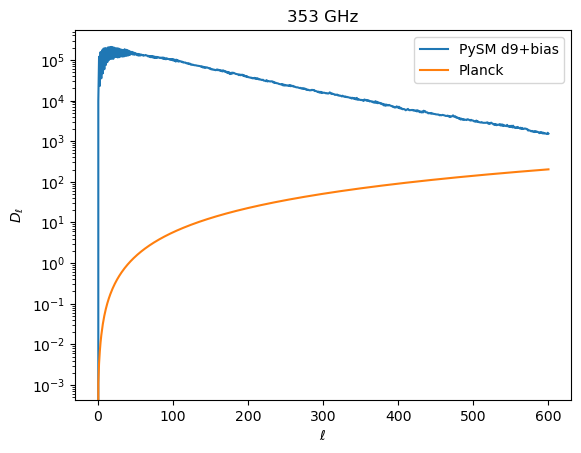

In [ ]:
dust = "d9"   # choose one model to test
biases, _ = bias_to_planck(dust)

for i, freq in enumerate(freqs):
    dust_map = pysmdict[dust][freq] + biases[i]  
    # For now, ignore noise and other fg for simplicity
    cl = hp.anafast(dust_map * mask, lmax=lmax)

    plt.figure()
    plt.plot(ells, ells * (ells+1) * cl / (2*np.pi), label=f"PySM {dust}+bias")
    plt.plot(ells, ells * (ells+1) * planckpsdict[freq] / (2*np.pi), label="Planck")
    plt.yscale("log")
    plt.title(f"{freq} GHz")
    plt.xlabel(r"$\ell$")
    plt.ylabel(r"$D_\ell$")
    plt.legend()
